# Mobile Inventory Restocking Tool V2 — EDA

Explores data quality, sentiment, markets, product demand proxies and model-ready features. Review volume is a demand proxy, not verified sales.

## 1. Load and inspect

In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
path=next((p for p in [Path("../Mobile Reviews Sentiment.csv"),Path("Mobile Reviews Sentiment.csv")] if p.exists()),None)
if path is None: raise FileNotFoundError("Mobile Reviews Sentiment.csv not found")
df=pd.read_csv(path)
df["review_date"]=pd.to_datetime(df["review_date"],errors="coerce")
df["price_inr"]=df["price_usd"]*87
df["is_positive"]=df["sentiment"].eq("Positive").astype(int)
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
display(df.head())

In [ ]:
quality=pd.DataFrame({"type":df.dtypes.astype(str),"missing":df.isna().sum(),"missing_pct":(100*df.isna().mean()).round(2),"unique":df.nunique()})
display(quality.sort_values("missing_pct",ascending=False))

## 2. Core exploratory diagrams

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(14,9))
df["sentiment"].value_counts().plot.bar(ax=ax[0,0],title="Sentiment distribution",color=["#59a14f","#e15759","#bab0ab"])
df["country"].value_counts().sort_values().plot.barh(ax=ax[0,1],title="Reviews by country",color="#4e79a7")
df["model"].value_counts().head(10).sort_values().plot.barh(ax=ax[1,0],title="Top models by review volume",color="#f28e2b")
df.groupby(df["review_date"].dt.to_period("M")).size().plot(ax=ax[1,1],title="Monthly review-volume trend",color="#9467bd",marker="o")
plt.tight_layout(); plt.show()

In [ ]:
summary=df.groupby("country").agg(reviews=("review_id","count"),positive_rate=("is_positive","mean"),average_rating=("rating","mean"),average_price_inr=("price_inr","mean")).sort_values("reviews",ascending=False)
summary["positive_rate"]=(100*summary["positive_rate"]).round(1)
display(summary.round(2))

## 3. Market-level correlation

The saved output below was generated from the bundled dataset. Encoded-category correlations are descriptive only.

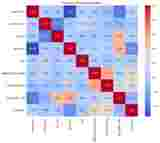

In [1]:
m=df.groupby(["country","model"]).agg(brand=("brand","first"),price_inr=("price_inr","mean"),age=("age","mean"),battery=("battery_life_rating","mean"),camera=("camera_rating","mean"),performance=("performance_rating","mean"),sentiment=("is_positive","mean"),volume=("review_id","count")).reset_index()
for c in ["brand","country"]: m[c+"_enc"]=LabelEncoder().fit_transform(m[c])
for country,g in m.groupby("country"):
 mask=m["country"].eq(country)&m["sentiment"].gt(g["sentiment"].quantile(.6))&m["volume"].gt(g["volume"].quantile(.5)); m.loc[mask,"is_winner"]=1
m["is_winner"]=m["is_winner"].fillna(0).astype(int)
cols=["brand_enc","country_enc","price_inr","age","battery","camera","performance","sentiment","volume","is_winner"]
plt.figure(figsize=(10,8)); sns.heatmap(m[cols].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0); plt.title("Market-level feature correlation"); plt.tight_layout(); plt.show()

## 4. Findings and cautions

- Compare sentiment and review volume by country before fitting a global model.
- Treat review counts as demand proxies until transaction data is available.
- Use ROC-AUC and stratified validation because the proxy winner label is imbalanced.
- Replace heuristic margins and returns with observed business data for production.